<a href="https://colab.research.google.com/github/jeniferGoncalvesDaSilvaDev/Introdu-o-Aprendizagem-por-Refor-o/blob/main/revis%C3%A3o_e_greedy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Funcionamento de E-greedy

Minha abordagem: utilizei a distribuição beta binomial para modelar a probabilidade de sucesso do agente de obter o valor esperado da recompensa, no caso do e-greedy argmax(Q(t))

Avaliar a probabilidade de sucesso do agente ao obter o melhor esperado da recompensa ao ir para a direita ou esquerda

Plotagem da política ótima inicial (antes da simulação):


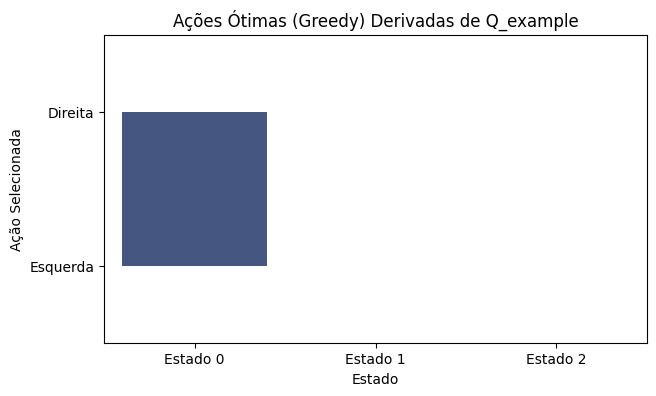


Iniciando uma pequena simulação para demonstrar a atualização de Q-values:
Estado inicial de Q para o Estado 0: [-1.   0.5]
Passo 1: Ação selecionada = 1, Recompensa = 0, Q atualizado = [-1.  0.]
Passo 2: Ação selecionada = 0, Recompensa = 0, Q atualizado = [0. 0.]
Passo 3: Ação selecionada = 1, Recompensa = 1, Q atualizado = [0.  0.5]
Passo 4: Ação selecionada = 1, Recompensa = 0, Q atualizado = [0.         0.33333333]
Passo 5: Ação selecionada = 1, Recompensa = 1, Q atualizado = [0.  0.5]
Passo 6: Ação selecionada = 1, Recompensa = 0, Q atualizado = [0.  0.4]
Passo 7: Ação selecionada = 1, Recompensa = 1, Q atualizado = [0.  0.5]
Passo 8: Ação selecionada = 1, Recompensa = 1, Q atualizado = [0.         0.57142857]
Passo 9: Ação selecionada = 1, Recompensa = 1, Q atualizado = [0.    0.625]
Passo 10: Ação selecionada = 1, Recompensa = 1, Q atualizado = [0.         0.66666667]
Passo 11: Ação selecionada = 1, Recompensa = 1, Q atualizado = [0.  0.7]
Passo 12: Ação selecionada = 0, Recom

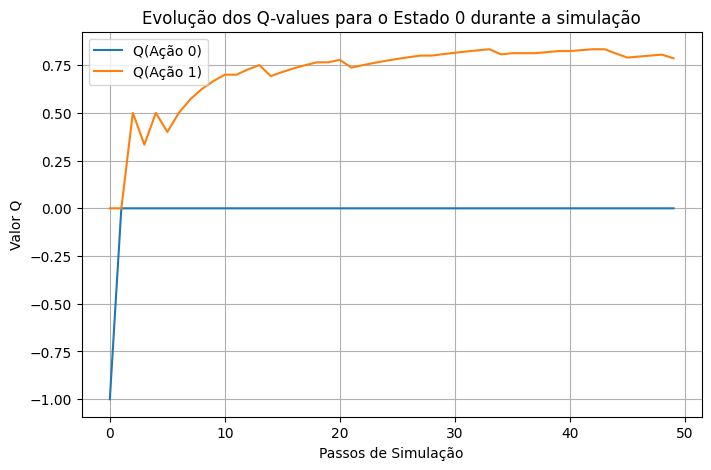

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def select_action_epsilon_greedy(Q_table, state, epsilon, num_actions):
    """Selects an action using an epsilon-greedy policy."""
    if np.random.rand() < epsilon:
        return np.random.randint(num_actions)  # Explore: Choose a random action
    else:
        # Exploit: Choose the action with the highest Q-value
        q_values = Q_table[state, :]
        max_q = np.max(q_values)
        # Get all actions that have the max Q-value (to handle ties)
        greedy_actions = np.where(q_values == max_q)[0]
        return np.random.choice(greedy_actions) # Choose randomly among the best actions


# --- Demonstração da função e-greedy ---

# Exemplo de uma tabela Q (Q-table) para 3 estados e 2 ações
# Cada linha representa um estado, cada coluna representa uma ação (0 = esquerda, 1 = direita)
# Os valores representam a 'qualidade' de tomar uma ação em um determinado estado.
Q_example = np.array([
    [-1.0, 0.5], # Estado 0: (melhor ir para direita)
    [ 2.0, 1.0], # Estado 1: (melhor ir para esquerda)
    [ 0.1, 0.1]  # Estado 2: (Q-valores iguais, escolherá aleatoriamente)
])

num_states = Q_example.shape[0]
num_actions = Q_example.shape[1]

# Definir o valor de epsilon (probabilidade de exploração)
epsilon_value = 0.3

def plot_optimal_actions():
    """
    Plots the greedy actions (optimal policy) derived from Q_example using seaborn.
    Assumes Q_example and num_states are globally available.
    """
    if 'Q_example' not in globals():
        print("Q_example not defined. Please define Q_example before calling plot_optimal_actions.")
        return

    greedy_policy = np.argmax(Q_example, axis=1)

    plt.figure(figsize=(7, 4))
    sns.barplot(x=[f'Estado {i}' for i in range(num_states)], y=greedy_policy, hue=[f'Estado {i}' for i in range(num_states)], palette='viridis', legend=False)
    plt.yticks([0, 1], ['Esquerda', 'Direita']) # Custom y-ticks for actions
    plt.title('Ações Ótimas (Greedy) Derivadas de Q_example')
    plt.xlabel('Estado')
    plt.ylabel('Ação Selecionada')
    plt.ylim(-0.5, 1.5) # Ensure both 0 and 1 are visible
    plt.show()

# Chamando a função de plotagem estática inicial
print("Plotagem da política ótima inicial (antes da simulação):")
plot_optimal_actions()

# --- Simulação e Atualização de Q-values (em alinhamento com o diagrama) ---
print("\nIniciando uma pequena simulação para demonstrar a atualização de Q-values:")

# Para simplificar, vamos simular interações em um único estado, digamos Estado 0.
# No mundo real, o agente transitaria entre estados.
sim_state = 0
num_simulation_steps = 50

# Para acompanhar quantas vezes cada ação foi tomada e para a atualização incremental da média
N_action_counts = np.zeros(num_actions)
# Usar uma cópia para simulação, para não alterar Q_example diretamente
Q_simulated = Q_example[sim_state, :].copy()

print(f"Estado inicial de Q para o Estado {sim_state}: {Q_simulated}")

# Definir uma recompensa verdadeira hipotética para as ações no sim_state
# Esta é a 'Recompensa verdadeira' do ambiente no diagrama
# Exemplo: Ação 0 (Esquerda) tem Q-valor inicial -1.0, Ação 1 (Direita) tem 0.5.
# Vamos dar uma recompensa real média baixa para Ação 0 e mais alta para Ação 1.
true_rewards_for_sim_state = np.array([0.1, 0.8]) # P(recompensa=1 | ação)

# Histórico das estimativas Q durante a simulação para plotagem
q_history = np.zeros((num_simulation_steps, num_actions))

for step in range(num_simulation_steps):
    # select_action_epsilon_greedy espera uma Q_table 2D, então passamos Q_simulated reshaped
    action = select_action_epsilon_greedy(Q_simulated.reshape(1, -1), 0, epsilon_value, num_actions)

    # Simular a recompensa (representando a 'Bernoulli' do diagrama)
    # Recompensa binária (0 ou 1) com probabilidade true_rewards_for_sim_state[action]
    reward = 1 if np.random.rand() < true_rewards_for_sim_state[action] else 0

    N_action_counts[action] += 1

    # Atualiza Q (representando a 'média incremental' do diagrama)
    # Q(a) += (reward - Q(a)) / N(a)
    Q_simulated[action] += (reward - Q_simulated[action]) / N_action_counts[action]

    q_history[step] = Q_simulated.copy() # Salvar o estado atual dos Q-valores simulados

    print(f"Passo {step+1}: Ação selecionada = {action}, Recompensa = {reward}, Q atualizado = {Q_simulated}")

print(f"\nQ-values finais simulados para o Estado {sim_state}: {Q_simulated}")
print(f"Contagem de ações tomadas: {N_action_counts}")

# Plotar a evolução dos Q-values durante a simulação
plt.figure(figsize=(8, 5))
for i in range(num_actions):
    plt.plot(q_history[:, i], label=f'Q(Ação {i})')
plt.title(f'Evolução dos Q-values para o Estado {sim_state} durante a simulação')
plt.xlabel('Passos de Simulação')
plt.ylabel('Valor Q')
plt.legend()
plt.grid(True)
plt.show()

### Modelagem da Incerteza com Distribuições Beta Binomial

Podemos usar a distribuição BetaBinomial para modelar a incerteza do agente sobre a probabilidade de sucesso de tomar uma ação ótima em cada estado. Esta abordagem é comum em problemas de *multi-armed bandits* e, por extensão, em Aprendizado por Reforço, onde o sucesso de uma ação pode ser visto como uma variável Bernoulli.

Cada distribuição Beta é definida por dois parâmetros: $\alpha$ (alpha) e $\beta$ (beta). Eles podem ser interpretados como o número de "sucessos" e "falhas" observados, respectivamente. Quanto mais observações temos, mais estreita a distribuição Beta se torna, refletindo menor incerteza.

Abaixo, uma classe `success_chance_enviroment_agent` é definida para:
1.  Calcular a probabilidade de sucesso de escolher uma ação ótima para cada estado, considerando a política $\epsilon$-greedy.
2.  Usar essa probabilidade para sintetizar "sucessos" e "falhas" hipotéticos que atualizam os parâmetros $\alpha$ e $\beta$ de uma distribuição Beta inicial (prior).
3.  Plotar essas distribuições Beta para visualizar a crença do agente sobre a chance de sucesso em cada estado.

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import beta, binom # Importar binom aqui

class SuccessChanceEnvironmentAgent:
    def __init__(self, Q_table, epsilon, num_actions):
        self.Q_table = Q_table
        self.epsilon = epsilon
        self.num_actions = num_actions

        # Inicializar o prior para a distribuição Beta para cada estado
        # Um prior não informativo comum é Beta(1,1) (distribuição uniforme)
        self.alpha_priors = np.ones(Q_table.shape[0])
        self.beta_priors = np.ones(Q_table.shape[0])

    def show_success_chance_environment(self, num_hypothetical_trials=10, plot_dist=True):
        """
        Modela a chance de sucesso (escolher uma ação ótima) para cada estado
        usando uma distribuição Beta, informada pela política epsilon-greedy.

        Args:
            num_hypothetical_trials (int): Número de tentativas hipotéticas para
                                           sintetizar sucessos/falhas efetivos.
            plot_dist (bool): Se deve ou não plotar as distribuições Beta e Binomial.
        """
        print("\nModelando a chance de sucesso (escolher a ação ótima) para cada estado usando Distribuição Beta e Binomial:")

        for s in range(self.Q_table.shape[0]):
            # 1. Identificar as ações ótimas para o estado atual
            q_values_state = self.Q_table[s, :]
            max_q = np.max(q_values_state)
            # Obter todas as ações que têm o valor Q máximo (para lidar com empates)
            optimal_actions = np.where(q_values_state == max_q)[0]
            num_optimal_actions = len(optimal_actions)

            # 2. Calcular a probabilidade teórica de escolher uma ação ótima
            #    baseada na política epsilon-greedy para este estado.
            p_exploit_optimal = (1 - self.epsilon) if num_optimal_actions > 0 else 0 # Se não houver ação ótima, não explora ótima
            p_explore_optimal = self.epsilon * (num_optimal_actions / self.num_actions)
            p_optimal_choice = p_exploit_optimal + p_explore_optimal

            # Garantir que p_optimal_choice esteja dentro de [0, 1]
            p_optimal_choice = np.clip(p_optimal_choice, 0, 1)

            # 3. Usar esta probabilidade para sintetizar 'sucessos' e 'falhas' efetivas
            #    para atualizar os parâmetros da distribuição Beta.
            # Estes são os 'dados observados' do seu diagrama que atualizam 'crença sobre p(a)'
            effective_successes = np.round(num_hypothetical_trials * p_optimal_choice)
            effective_failures = np.round(num_hypothetical_trials * (1 - p_optimal_choice))

            # Adicionar aos contadores prior para obter os parâmetros Beta posteriores
            alpha_posterior = self.alpha_priors[s] + effective_successes
            beta_posterior = self.beta_priors[s] + effective_failures

            print(f"Estado {s}:")
            print(f"  Probabilidade teórica de escolher uma ação ótima (P_optimal_choice): {p_optimal_choice:.4f}")
            print(f"  Parâmetros da Distribuição Beta Posterior: alpha={alpha_posterior:.2f}, beta={beta_posterior:.2f}")
            estimated_success_chance = alpha_posterior / (alpha_posterior + beta_posterior)
            print(f"  Média da Distribuição Beta (chance de sucesso estimada): {estimated_success_chance:.4f}")
            print(f"  Dados Hipotéticos para Binomial: Tentativas={num_hypothetical_trials}, Sucessos Esperados (arredondados)={effective_successes:.0f}")

            # Adição para verificar a proximidade
            if np.isclose(estimated_success_chance, p_optimal_choice, atol=0.05):
                print(f"  A chance de sucesso estimada ({estimated_success_chance:.4f}) está próxima da probabilidade teórica ({p_optimal_choice:.4f}).")
            else:
                print(f"  A chance de sucesso estimada ({estimated_success_chance:.4f}) difere da probabilidade teórica ({p_optimal_choice:.4f}).")

            if plot_dist:
                # Plot da Distribuição Beta
                x_beta = np.linspace(0, 1, 100)
                plt.figure(figsize=(12, 4))
                plt.subplot(1, 2, 1) # Subplot para a Beta
                plt.plot(x_beta, beta.pdf(x_beta, alpha_posterior, beta_posterior),
                         label=f'Estado {s} (Beta({alpha_posterior:.1f}, {beta_posterior:.1f}))')
                plt.title(f'Distribuição Posterior da Chance de Sucesso para o Estado {s}')
                plt.xlabel('Probabilidade de Sucesso (p)')
                plt.ylabel('Densidade de Probabilidade')
                plt.axvline(p_optimal_choice, color='r', linestyle='--', label='P_optimal_choice Teórico')
                plt.legend()
                plt.grid(True)

                # Plot da Distribuição Binomial (para k sucessos em num_hypothetical_trials)
                k_binom = np.arange(0, num_hypothetical_trials + 1)
                pmf_binom = binom.pmf(k_binom, num_hypothetical_trials, p_optimal_choice)

                plt.subplot(1, 2, 2) # Subplot para a Binomial
                plt.bar(k_binom, pmf_binom, color='skyblue', label=f'Binomial(n={num_hypothetical_trials}, p={p_optimal_choice:.2f})')
                plt.title(f'Distribuição Binomial de Sucessos para o Estado {s}')
                plt.xlabel('Número de Sucessos (k)')
                plt.ylabel('Probabilidade (PMF)')
                plt.legend()
                plt.grid(True)

                plt.tight_layout()
                plt.show()

# --- Demonstração de uso da classe ---


Modelando a chance de sucesso (escolher a ação ótima) para cada estado usando Distribuição Beta e Binomial:
Estado 0:
  Probabilidade teórica de escolher uma ação ótima (P_optimal_choice): 0.8500
  Parâmetros da Distribuição Beta Posterior: alpha=18.00, beta=4.00
  Média da Distribuição Beta (chance de sucesso estimada): 0.8182
  Dados Hipotéticos para Binomial: Tentativas=20, Sucessos Esperados (arredondados)=17
  A chance de sucesso estimada (0.8182) está próxima da probabilidade teórica (0.8500).


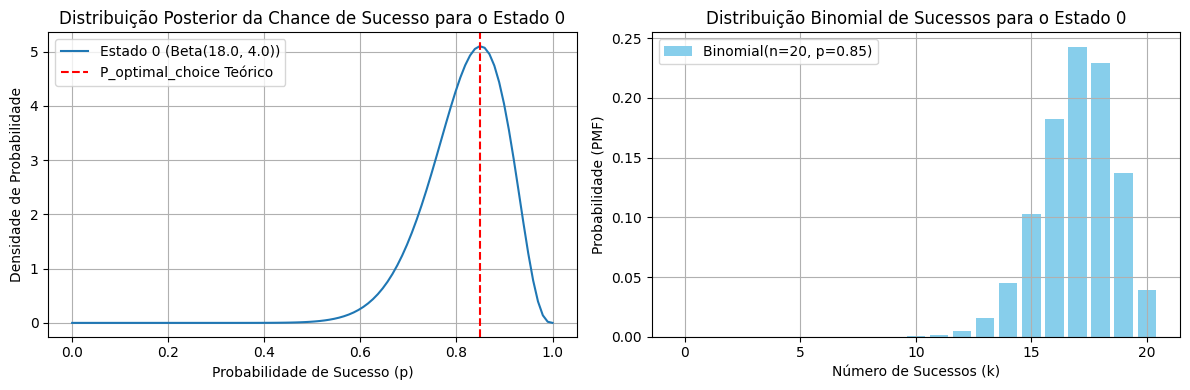

Estado 1:
  Probabilidade teórica de escolher uma ação ótima (P_optimal_choice): 0.8500
  Parâmetros da Distribuição Beta Posterior: alpha=18.00, beta=4.00
  Média da Distribuição Beta (chance de sucesso estimada): 0.8182
  Dados Hipotéticos para Binomial: Tentativas=20, Sucessos Esperados (arredondados)=17
  A chance de sucesso estimada (0.8182) está próxima da probabilidade teórica (0.8500).


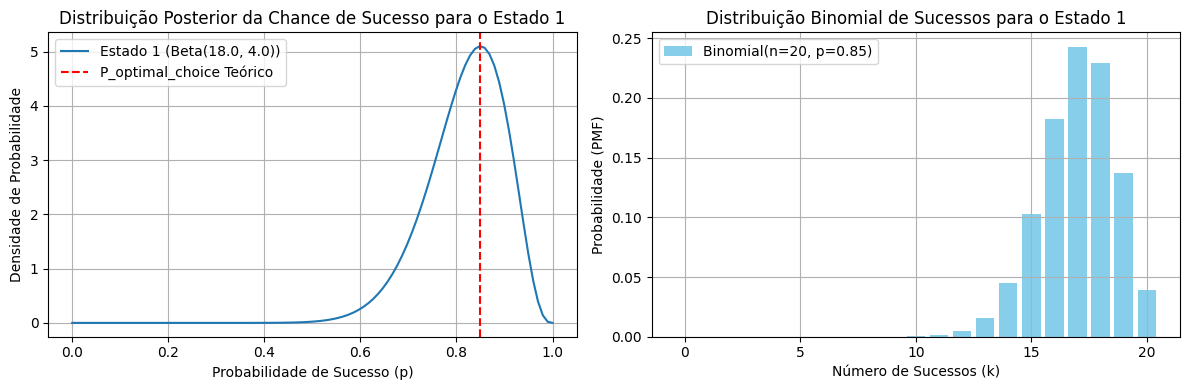

Estado 2:
  Probabilidade teórica de escolher uma ação ótima (P_optimal_choice): 1.0000
  Parâmetros da Distribuição Beta Posterior: alpha=21.00, beta=1.00
  Média da Distribuição Beta (chance de sucesso estimada): 0.9545
  Dados Hipotéticos para Binomial: Tentativas=20, Sucessos Esperados (arredondados)=20
  A chance de sucesso estimada (0.9545) está próxima da probabilidade teórica (1.0000).


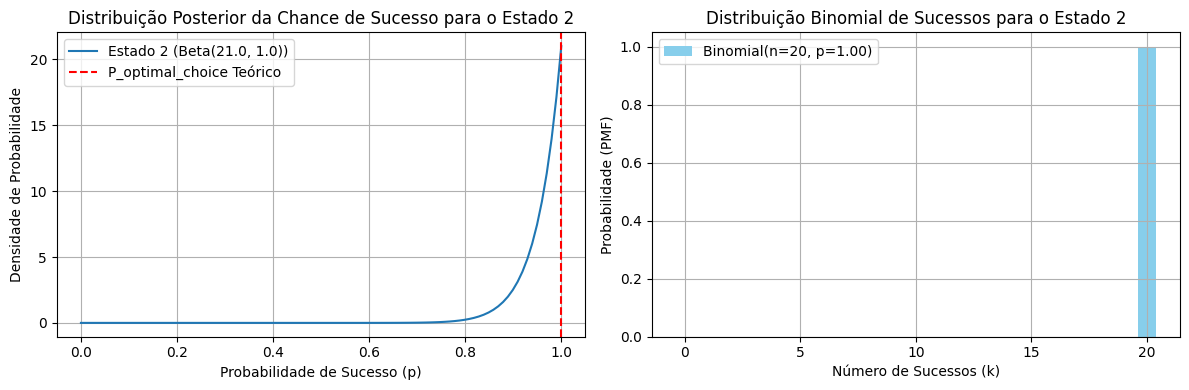

In [13]:
# Usando os valores já definidos no notebook
# Q_example, epsilon_value, num_actions

agent_beta_model = SuccessChanceEnvironmentAgent(Q_example, epsilon_value, num_actions)
agent_beta_model.show_success_chance_environment(num_hypothetical_trials=20)

Código mostrado na aula

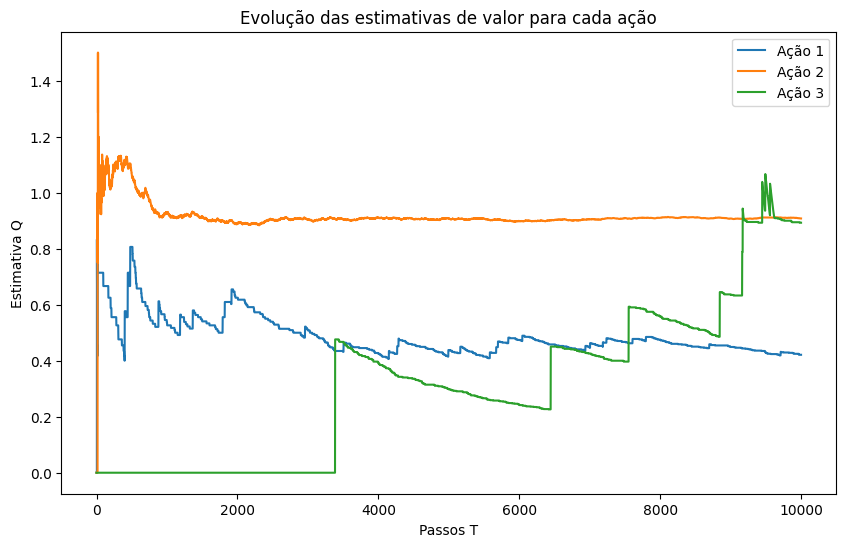

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Número de ações/braços do bandit
k = 3

# Probabilidade de explorar aleatoriamente
epsilon = 0.1

# Número de passos da simulação
steps = 10000

# Probabilidades reais de sucesso de cada braço
probs = np.array([0.1, 0.3, 0.01])

# Recompensa associada a cada braço quando há sucesso
rewards = np.array([5, 3, 50])

# Estimativa de valor Q de cada ação
Q = np.zeros(k)

# Contador de quantas vezes cada ação foi escolhida
N = np.zeros(k)

# Histórico das estimativas ao longo do tempo
history = np.zeros((steps, k))

# Loop principal da simulação
for t in range(steps):
    # Decisão epsilon-greedy:
    # com probabilidade epsilon escolhe aleatoriamente
    if np.random.random() < epsilon:
        action = np.random.randint(k)
    else:
        # caso contrário, escolhe a ação com maior estimativa Q
        action = np.argmax(Q)

    # Sorteia se houve recompensa ou não
    # Se o sorteio for menor que a probabilidade do braço, recebe reward
    reward = rewards[action] if np.random.random() < probs[action] else 0

    # Atualiza o número de vezes que essa ação foi usada
    N[action] += 1

    # Atualiza a estimativa Q pelo método incremental da média
    Q[action] += (reward - Q[action]) / N[action]

    # Guarda o estado atual de Q no histórico
    history[t] = Q.copy()

# Cria a figura do gráfico
plt.figure(figsize=(10, 6))

# Plota a evolução de cada ação
for i in range(k):
    plt.plot(history[:, i], label=f'Ação {i + 1}')

# Nome dos eixos
plt.xlabel('Passos T')
plt.ylabel('Estimativa Q')

# Título do gráfico
plt.title('Evolução das estimativas de valor para cada ação')

# Mostra a legenda
plt.legend()

# Exibe o gráfico
plt.show()